In [1]:
# Standard library imports
import time
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer

# Scikit-learn — models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC

#pipeline
from sklearn.pipeline import Pipeline

# Scikit-learn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv('../data/bank-full.csv', sep=';')

In [3]:
#drop duration
df = df.drop(columns=['duration'])

#encode as binary
df['y'] = (df['y'] == 'yes').astype(int)

#change pdays to binary because 999 implies no prior contact, changing it to 0 might skew the model
df['p_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])  



In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [5]:
X = df.drop('y', axis=1, inplace=False)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Dummy Classifier
Determine Baseline

In [6]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
)

dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42)),
])

dummy_pipe.fit(X_train, y_train)
y_pred_dummy = dummy_pipe.predict(X_test)
y_prob_dummy = dummy_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dummy):.4f}")
print()
print(classification_report(y_test, y_pred_dummy, target_names=['no', 'yes']))

Accuracy : 0.8803
ROC-AUC  : 0.5000

              precision    recall  f1-score   support

          no       0.88      1.00      0.94      9950
         yes       0.00      0.00      0.00      1353

    accuracy                           0.88     11303
   macro avg       0.44      0.50      0.47     11303
weighted avg       0.77      0.88      0.82     11303



### Logistic Regression Pipeline
Build a full preprocessing + model pipeline using `StandardScaler` for numeric features and `OneHotEncoder` for categorical features.

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
)

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)
y_prob = lr_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

Accuracy : 0.8908
ROC-AUC  : 0.7614

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      9950
         yes       0.66      0.18      0.29      1353

    accuracy                           0.89     11303
   macro avg       0.78      0.58      0.61     11303
weighted avg       0.87      0.89      0.86     11303



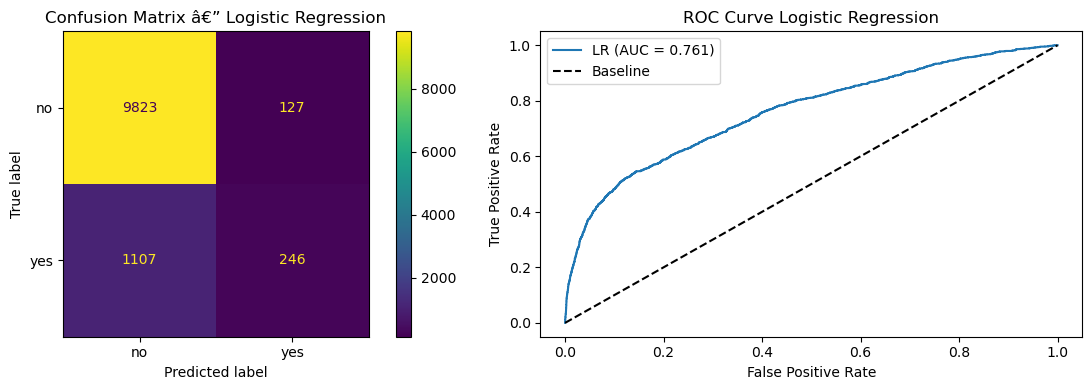

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix â€” Logistic Regression')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'LR (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

### Logistic Regression Stratified K-Fold Cross-Validation
Evaluate the same pipeline with 5-fold stratified cross-validation to get a more robust estimate of generalisation performance.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(lr_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc  = cross_val_score(lr_pipe, X, y, cv=skf, scoring='roc_auc')

print("Logistic Regression 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy.mean():.4f}  (+/- {cv_accuracy.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc.mean():.4f}  (+/- {cv_roc_auc.std():.4f})")

cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy,
    'ROC-AUC': cv_roc_auc,
})
print()
print(cv_results.to_string(index=False))

Logistic Regression 5-Fold Stratified CV
  Accuracy : 0.8925  (+/- 0.0015)
  ROC-AUC  : 0.7654  (+/- 0.0085)

 Fold  Accuracy  ROC-AUC
    1  0.891408 0.757772
    2  0.894382 0.774366
    3  0.892833 0.755807
    4  0.890069 0.762764
    5  0.893608 0.776490


### K-Nearest Neighbors Pipeline
Same preprocessing pipeline with `KNeighborsClassifier` as the estimator.

In [10]:
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier()),
])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_prob_knn = knn_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['no', 'yes']))

Accuracy : 0.8867
ROC-AUC  : 0.6903

              precision    recall  f1-score   support

          no       0.90      0.98      0.94      9950
         yes       0.58      0.19      0.29      1353

    accuracy                           0.89     11303
   macro avg       0.74      0.59      0.61     11303
weighted avg       0.86      0.89      0.86     11303



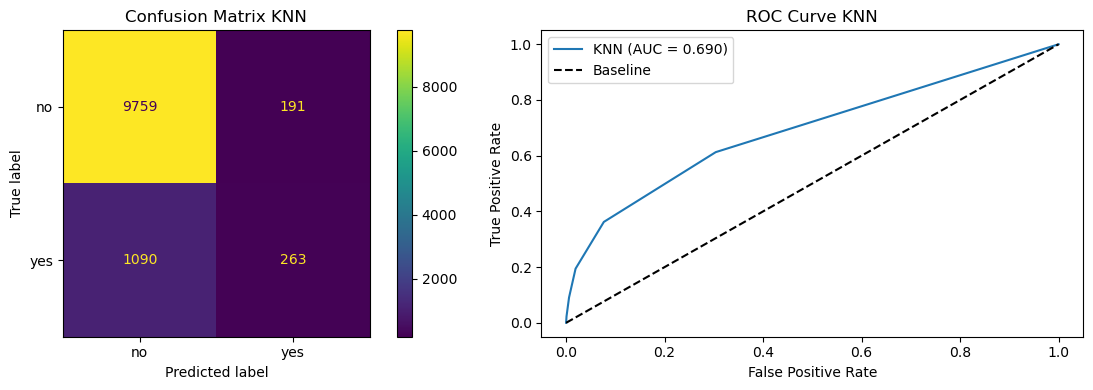

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix KNN')

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
axes[1].plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve KNN')
axes[1].legend()

plt.tight_layout()
plt.show()

### KNN â€” Stratified K-Fold Cross-Validation

In [12]:
cv_accuracy_knn = cross_val_score(knn_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_knn  = cross_val_score(knn_pipe, X, y, cv=skf, scoring='roc_auc')

print("KNN 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_knn.mean():.4f}  (+/- {cv_accuracy_knn.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_knn.mean():.4f}  (+/- {cv_roc_auc_knn.std():.4f})")

cv_results_knn = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_knn,
    'ROC-AUC': cv_roc_auc_knn,
})
print()
print(cv_results_knn.to_string(index=False))

KNN 5-Fold Stratified CV
  Accuracy : 0.8862  (+/- 0.0006)
  ROC-AUC  : 0.6878  (+/- 0.0115)

 Fold  Accuracy  ROC-AUC
    1  0.885768 0.685084
    2  0.886640 0.703712
    3  0.885977 0.689840
    4  0.885645 0.668443
    5  0.887193 0.691859


### Decision Tree Pipeline

In [13]:
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42)),
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['no', 'yes']))

Accuracy : 0.8255
ROC-AUC  : 0.6139

              precision    recall  f1-score   support

          no       0.91      0.89      0.90      9950
         yes       0.30      0.34      0.32      1353

    accuracy                           0.83     11303
   macro avg       0.60      0.61      0.61     11303
weighted avg       0.83      0.83      0.83     11303



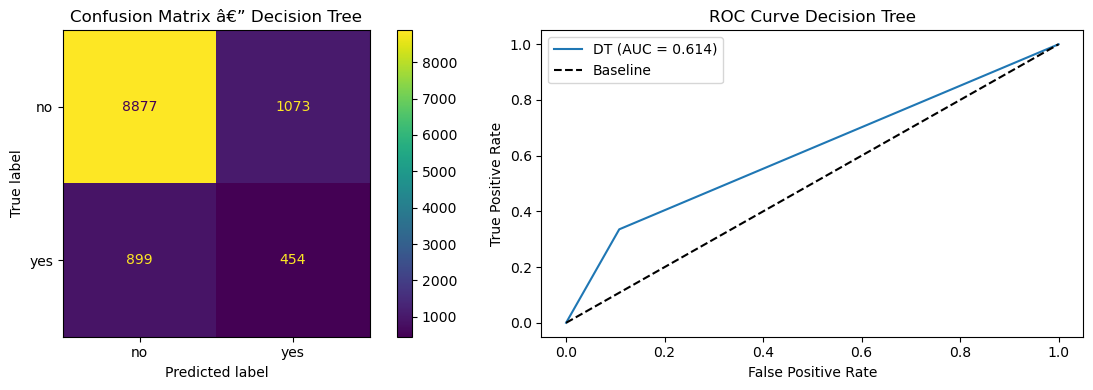

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix â€” Decision Tree')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
axes[1].plot(fpr_dt, tpr_dt, label=f'DT (AUC = {auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Decision Tree')
axes[1].legend()

plt.tight_layout()
plt.show()

### Decision Tree â€” Stratified K-Fold Cross-Validation

In [15]:
cv_accuracy_dt = cross_val_score(dt_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_dt  = cross_val_score(dt_pipe, X, y, cv=skf, scoring='roc_auc')

print("Decision Tree 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_dt.mean():.4f}  (+/- {cv_accuracy_dt.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_dt.mean():.4f}  (+/- {cv_roc_auc_dt.std():.4f})")

cv_results_dt = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_dt,
    'ROC-AUC': cv_roc_auc_dt,
})
print()
print(cv_results_dt.to_string(index=False))

Decision Tree 5-Fold Stratified CV
  Accuracy : 0.8289  (+/- 0.0024)
  ROC-AUC  : 0.6139  (+/- 0.0042)

 Fold  Accuracy  ROC-AUC
    1  0.829924 0.613844
    2  0.825039 0.614466
    3  0.827582 0.608833
    4  0.832338 0.611116
    5  0.829463 0.621376


### Support Vector Machine Pipeline

In [16]:
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(C=1.0, max_iter=2000, random_state=42, kernel='sigmoid')),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
y_score_svm = svm_pipe.decision_function(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_score_svm):.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=['no', 'yes']))

Accuracy : 0.5420
ROC-AUC  : 0.4818

              precision    recall  f1-score   support

          no       0.88      0.56      0.68      9950
         yes       0.11      0.42      0.18      1353

    accuracy                           0.54     11303
   macro avg       0.50      0.49      0.43     11303
weighted avg       0.78      0.54      0.62     11303



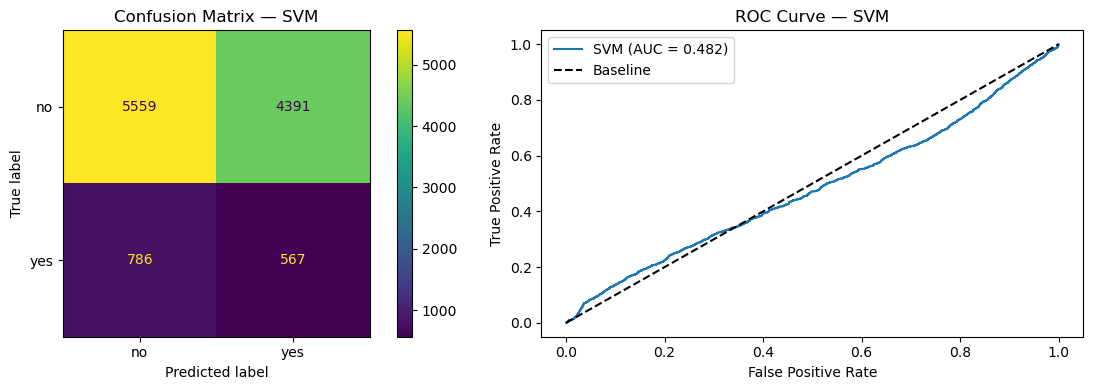

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix — SVM')

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = roc_auc_score(y_test, y_score_svm)
axes[1].plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — SVM')
axes[1].legend()

plt.tight_layout()
plt.show()

### SVM Stratified K-Fold Cross-Validation

In [18]:
cv_accuracy_svm = cross_val_score(svm_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_svm  = cross_val_score(svm_pipe, X, y, cv=skf, scoring='roc_auc')

print("SVM â€” 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_svm.mean():.4f}  (+/- {cv_accuracy_svm.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_svm.mean():.4f}  (+/- {cv_roc_auc_svm.std():.4f})")

cv_results_svm = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_svm,
    'ROC-AUC': cv_roc_auc_svm,
})
print()
print(cv_results_svm.to_string(index=False))

SVM â€” 5-Fold Stratified CV
  Accuracy : 0.5272  (+/- 0.0686)
  ROC-AUC  : 0.5061  (+/- 0.0437)

 Fold  Accuracy  ROC-AUC
    1  0.617494 0.524903
    2  0.455651 0.469849
    3  0.482084 0.478920
    4  0.477660 0.472991
    5  0.603296 0.583966


### GridSearchCV Hyperparameter Tuning Across All Models
Run `GridSearchCV` with `StratifiedKFold` for each model, log wall-clock time, then compare best scores side by side.

In [19]:
param_grids = {
    'Logistic Regression': {
        'pipe': lr_pipe,
        'params': {
            'model__C':      [0.01, 0.1, 1, 10],
            'model__solver': ['lbfgs', 'liblinear'],
        },
    },
    'KNN': {
        'pipe': knn_pipe,
        'params': {
            'model__n_neighbors': [3, 5, 11, 21],
            'model__weights':     ['uniform', 'distance'],
            'model__metric':      ['euclidean', 'manhattan'],
        },
    },
    'Decision Tree': {
        'pipe': dt_pipe,
        'params': {
            'model__max_depth':        [3, 5, 10, None],
            'model__min_samples_split': [2, 10, 20],
            'model__criterion':        ['gini', 'entropy'],
        },
    },
    'SVM': {
        'pipe': svm_pipe,
        'params': {
            'model__C': [0.001, 0.01, 0.1, 1],
            'model__kernel': ['poly', 'linear', 'sigmoid'],
        },
    },
}

gs_results = []

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    start = time.time()

    gs = GridSearchCV(
        config['pipe'],
        config['params'],
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X_train, y_train)

    elapsed = time.time() - start

    # Time the best estimator's training on the full training set
    best_est = gs.best_estimator_
    t0 = time.time()
    best_est.fit(X_train, y_train)
    train_time = time.time() - t0

    # Time prediction on the test set
    t0 = time.time()
    y_pred_gs = best_est.predict(X_test)
    predict_time = time.time() - t0

    if hasattr(best_est, 'predict_proba'):
        y_score_gs = best_est.predict_proba(X_test)[:, 1]
    else:
        y_score_gs = best_est.decision_function(X_test)

    gs_results.append({
        'Model':           name,
        'Best Params':     gs.best_params_,
        'CV ROC-AUC':      round(gs.best_score_, 4),
        'Test Accuracy':   round(accuracy_score(y_test, y_pred_gs), 4),
        'Test ROC-AUC':    round(roc_auc_score(y_test, y_score_gs), 4),
        'GridSearch (s)':  round(elapsed, 2),
        'Train Time (s)':  round(train_time, 4),
        'Predict Time (s)': round(predict_time, 4),
        'best_estimator':  best_est,
        'y_pred':          y_pred_gs,
        'y_score':         y_score_gs,
    })

    print(f"  Best params  : {gs.best_params_}")
    print(f"  CV ROC-AUC   : {gs.best_score_:.4f}")
    print(f"  Test Acc     : {accuracy_score(y_test, y_pred_gs):.4f}")
    print(f"  Test ROC-AUC : {roc_auc_score(y_test, y_score_gs):.4f}")
    print(f"  GridSearch   : {elapsed:.2f}s")
    print(f"  Train time   : {train_time:.4f}s")
    print(f"  Predict time : {predict_time:.4f}s")
    print()

Tuning Logistic Regression...
  Best params  : {'model__C': 0.1, 'model__solver': 'liblinear'}
  CV ROC-AUC   : 0.7665
  Test Acc     : 0.8907
  Test ROC-AUC : 0.7615
  GridSearch   : 4.77s
  Train time   : 0.1105s
  Predict time : 0.0178s

Tuning KNN...
  Best params  : {'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'distance'}
  CV ROC-AUC   : 0.7400
  Test Acc     : 0.8891
  Test ROC-AUC : 0.7558
  GridSearch   : 19.84s
  Train time   : 0.0559s
  Predict time : 1.2522s

Tuning Decision Tree...
  Best params  : {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_split': 20}
  CV ROC-AUC   : 0.7367
  Test Acc     : 0.8875
  Test ROC-AUC : 0.7415
  GridSearch   : 3.32s
  Train time   : 0.1709s
  Predict time : 0.0183s

Tuning SVM...
  Best params  : {'model__C': 0.001, 'model__kernel': 'linear'}
  CV ROC-AUC   : 0.6109
  Test Acc     : 0.1197
  Test ROC-AUC : 0.5611
  GridSearch   : 70.94s
  Train time   : 2.8637s
  Predict time : 0.6

In [20]:
exclude_keys = ('Best Params', 'best_estimator', 'y_pred', 'y_score')
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k not in exclude_keys} for r in gs_results])
print(summary_df.to_string(index=False))

              Model  CV ROC-AUC  Test Accuracy  Test ROC-AUC  GridSearch (s)  Train Time (s)  Predict Time (s)
Logistic Regression      0.7665         0.8907        0.7615            4.77          0.1105            0.0178
                KNN      0.7400         0.8891        0.7558           19.84          0.0559            1.2522
      Decision Tree      0.7367         0.8875        0.7415            3.32          0.1709            0.0183
                SVM      0.6109         0.1197        0.5611           70.94          2.8637            0.6515


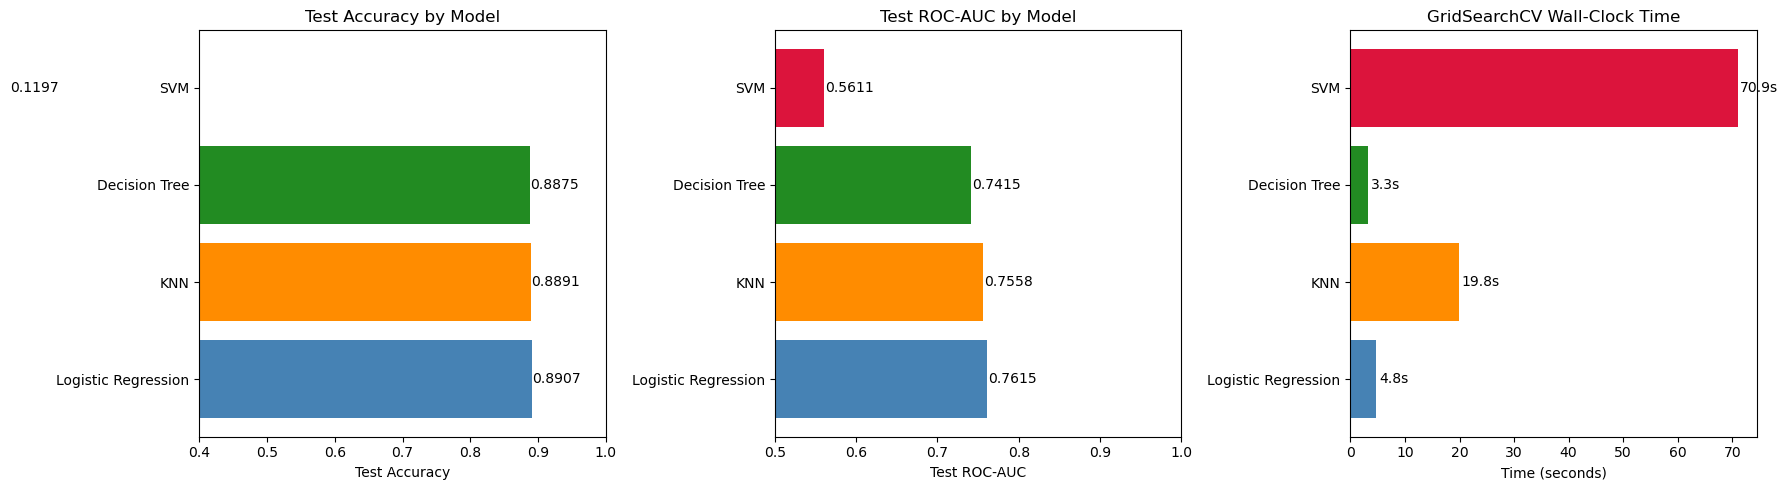

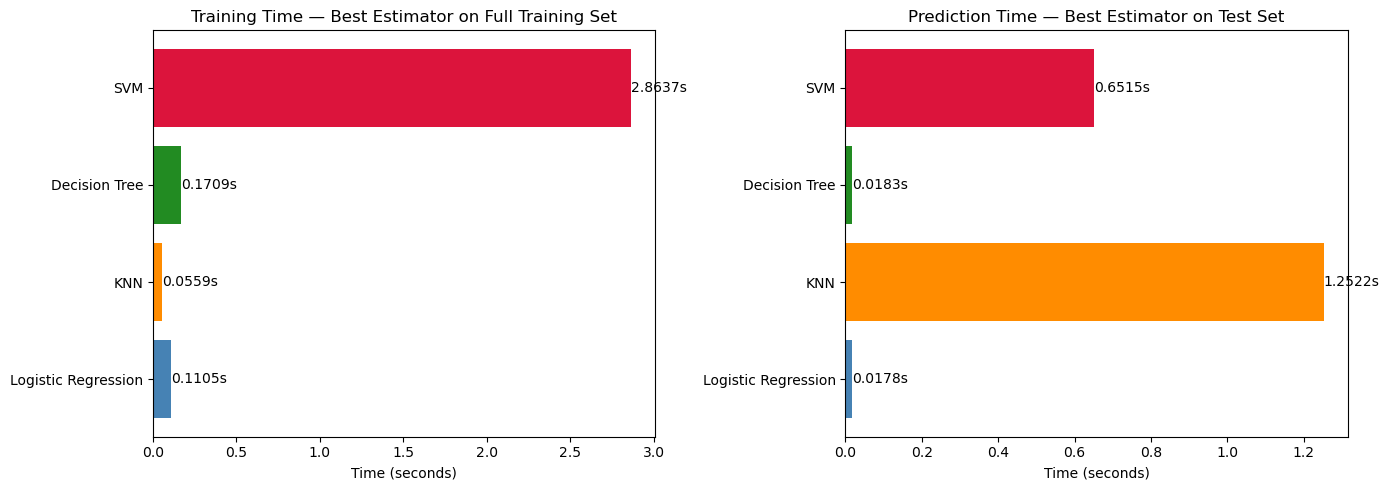

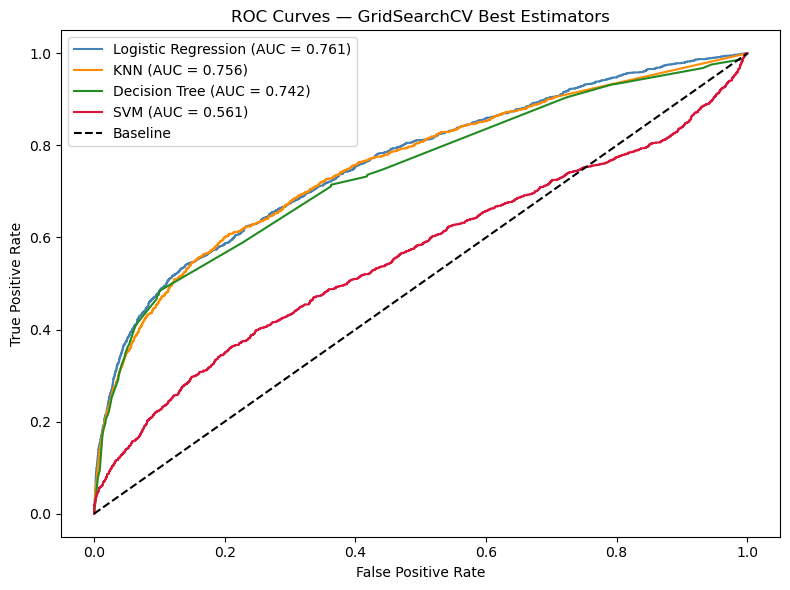

Speed Summary
  Fastest to train   : KNN
  Slowest to train   : SVM
  Fastest to predict : Logistic Regression
  Slowest to predict : KNN

              Model  Train Time (s)  Predict Time (s)
Logistic Regression          0.1105            0.0178
                KNN          0.0559            1.2522
      Decision Tree          0.1709            0.0183
                SVM          2.8637            0.6515


In [21]:
models       = summary_df['Model']
test_acc     = summary_df['Test Accuracy']
test_auc     = summary_df['Test ROC-AUC']
gs_times     = summary_df['GridSearch (s)']
train_times  = summary_df['Train Time (s)']
predict_times = summary_df['Predict Time (s)']
colors       = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

# --- Performance + GridSearch time ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(models, test_acc, color=colors)
axes[0].set_xlim(0.4, 1.0)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Model')
for i, v in enumerate(test_acc):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center')

axes[1].barh(models, test_auc, color=colors)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel('Test ROC-AUC')
axes[1].set_title('Test ROC-AUC by Model')
for i, v in enumerate(test_auc):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center')

axes[2].barh(models, gs_times, color=colors)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('GridSearchCV Wall-Clock Time')
for i, v in enumerate(gs_times):
    axes[2].text(v + 0.5, i, f'{v:.1f}s', va='center')

plt.tight_layout()
plt.show()

# --- Training vs Prediction time ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(models, train_times, color=colors)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_title('Training Time — Best Estimator on Full Training Set')
for i, v in enumerate(train_times):
    axes[0].text(v + 0.0005, i, f'{v:.4f}s', va='center')

axes[1].barh(models, predict_times, color=colors)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Prediction Time — Best Estimator on Test Set')
for i, v in enumerate(predict_times):
    axes[1].text(v + 0.0001, i, f'{v:.4f}s', va='center')

plt.tight_layout()
plt.show()

# --- ROC curves overlaid ---
fig, ax = plt.subplots(figsize=(8, 6))
for r, color in zip(gs_results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_score'])
    ax.plot(fpr, tpr, label=f"{r['Model']} (AUC = {r['Test ROC-AUC']:.3f})", color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — GridSearchCV Best Estimators')
ax.legend()
plt.tight_layout()
plt.show()

# --- Speed comparison callout ---
fastest_train  = summary_df.loc[summary_df['Train Time (s)'].idxmin(), 'Model']
slowest_train  = summary_df.loc[summary_df['Train Time (s)'].idxmax(), 'Model']
fastest_pred   = summary_df.loc[summary_df['Predict Time (s)'].idxmin(), 'Model']
slowest_pred   = summary_df.loc[summary_df['Predict Time (s)'].idxmax(), 'Model']

print("Speed Summary")
print("=" * 50)
print(f"  Fastest to train   : {fastest_train}")
print(f"  Slowest to train   : {slowest_train}")
print(f"  Fastest to predict : {fastest_pred}")
print(f"  Slowest to predict : {slowest_pred}")
print()
print(summary_df[['Model', 'Train Time (s)', 'Predict Time (s)']].to_string(index=False))

### Logistic Regression Coefficient Plot
Coefficients show the direction and magnitude of each feature's influence on the log-odds of a `yes` subscription outcome. Positive = increases likelihood, negative = decreases it.

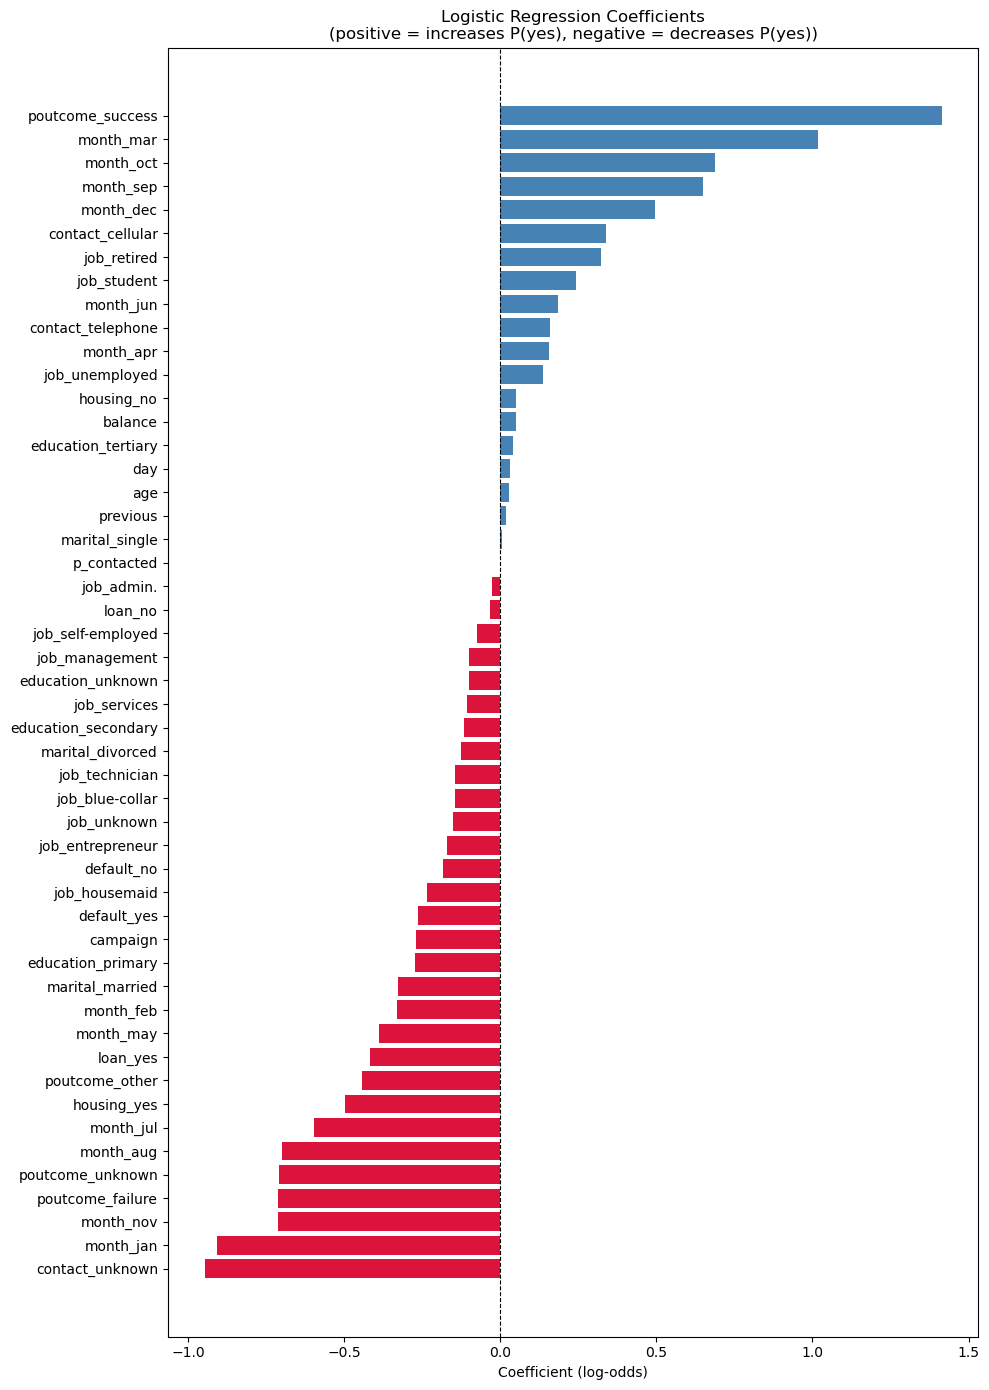

In [22]:
# Use the best LR estimator from GridSearchCV
best_lr = gs_results[0]['best_estimator']

# Recover feature names from the fitted preprocessor
ohe_features = (best_lr.named_steps['preprocessor']
                        .named_transformers_['onehotencoder']
                        .get_feature_names_out(cat_cols))
feature_names = num_cols + list(ohe_features)

# Extract coefficients (shape: 1 x n_features for binary classification)
coefs = best_lr.named_steps['model'].coef_[0]

coef_df = (pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
             .sort_values('Coefficient', ascending=False))

# Split positive / negative for colour coding
colors = ['steelblue' if c > 0 else 'crimson' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.28)))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression Coefficients\n(positive = increases P(yes), negative = decreases P(yes))')
ax.invert_yaxis()
plt.tight_layout()
plt.show()